In [22]:
"""
Train script:
- reads data/raw/Phishing_URL_Dataset.csv (or processed CSV if present)
- auto-detects URL column & label column
- builds features, scales, trains SimpleTabNet
- saves artifacts to src/serve/artifacts/: model.pt, scaler.pkl, feature_keys.json
"""

import os
import json
import joblib
import numpy as np
import pandas as pd
from typing import List, Tuple
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, confusion_matrix
import torch
import torch.nn as nn
#from .tabm_adapters import RefTABMNet
#from .features.reference_features import build_reference_features

In [2]:
import torch
import torch.nn as nn

class SimpleTabNet(nn.Module):
    """
    Compact TabNet-like MLP for tabular signals.
    Keep layer sizes modest for fast inference in a service worker loop.
    """
    def __init__(self, input_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, 1)  # binary
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [3]:
import torch
#from .tabnet_backbone import SimpleTabNet

class RefTABMNet:
    def __init__(self, input_dim: int, model_path: str = None, device: str = "cpu"):
        self.device = device
        self.model = SimpleTabNet(input_dim)
        if model_path:
            self.model.load_state_dict(torch.load(model_path, map_location=device))
        self.model.to(device)
        self.model.eval()

    @torch.inference_mode()
    def predict_proba(self, X):
        import numpy as np
        x = torch.tensor(X, dtype=torch.float32, device=self.device)
        logits = self.model(x)
        probs = torch.sigmoid(logits).detach().cpu().numpy().astype(float)
        return probs


In [4]:
import re
import ipaddress
from urllib.parse import urlparse
from typing import Dict

def _is_ip(host: str) -> int:
    try:
        ipaddress.ip_address(host)
        return 1
    except Exception:
        return 0

def extract_basic_url_features(url: str) -> Dict[str, float]:
    """
    General, model-agnostic URL features. Keep this PURE (no global state).
    """
    try:
        p = urlparse(url.strip())
    except Exception:
        # fall back: treat entire string as path
        p = urlparse("http://" + url.strip())

    scheme = (p.scheme or "").lower()
    host = (p.netloc or "").lower()
    path = (p.path or "").lower()
    query = p.query or ""
    fragment = p.fragment or ""

    host_no_port = host.split(":")[0]
    features = {
        "https": 1.0 if scheme == "https" else 0.0,
        "has_ip": float(_is_ip(host_no_port)),
        "len_url": float(len(url)),
        "len_host": float(len(host_no_port)),
        "len_path": float(len(path)),
        "num_dots_host": float(host_no_port.count(".")),
        "num_hyphen_host": float(host_no_port.count("-")),
        "num_digits_url": float(len(re.findall(r"\d", url))),
        "num_query_params": float(len(query.split("&")) if query else 0),
        "has_at": 1.0 if "@" in url else 0.0,
        "has_frag": 1.0 if fragment else 0.0,
        "path_depth": float(len([t for t in path.split("/") if t])),
    }
    return features

In [5]:
import re
from collections import Counter
from typing import Dict
#from .preprocess import extract_basic_url_features

# lightweight token dictionaries; you can expand from data stats during training
BENIGN_HINTS = {"about", "contact", "home", "help", "docs", "support", "community", "blog", "shop"}
PHISH_HINTS  = {"verify", "confirm", "update", "secure", "account", "wallet", "password", "bank", "login"}

def build_reference_features(url: str) -> Dict[str, float]:
    base = extract_basic_url_features(url)
    toks = [t for t in re.split(r"[\W_]+", url.lower()) if t]
    counts = Counter(toks)
    base["ref_phish_hits"] = float(sum(counts[t] for t in PHISH_HINTS if t in counts))
    base["ref_benign_hits"] = float(sum(counts[t] for t in BENIGN_HINTS if t in counts))
    # heuristic: ratio (avoid div-by-zero)
    denom = base["ref_benign_hits"] + 1.0
    base["ref_ratio"] = base["ref_phish_hits"] / denom
    return base

In [14]:
RAW_CSV = os.path.join("Phishing_URL_Dataset.csv")
PROC_CSV = os.path.join("processed_phishing_urls.csv")
ART_DIR = os.path.join("src", "serve", "artifacts")
os.makedirs(ART_DIR, exist_ok=True)

In [18]:
def _pick_cols(df: pd.DataFrame) -> Tuple[str, str]:
    # guess url column
    url_candidates = [c for c in df.columns if c.lower() in {"url", "urls", "link", "domain"}]
    if not url_candidates:
        raise ValueError("Could not find URL column (expected one of: url, urls, link, domain).")
    url_col = url_candidates[0]

    # guess label column
    label_candidates = [c for c in df.columns if c.lower() in {"label", "class", "target", "phishing", "encoded_label"}]
    if not label_candidates:
        raise ValueError("Could not find label column (expected one of: label, class, target, phishing).")
    y_col = label_candidates[0]
    return url_col, y_col

In [19]:
def featurize(urls: List[str]) -> Tuple[np.ndarray, List[str]]:
    rows = [build_reference_features(u) for u in urls]
    # fixed order of features
    keys = [
        "https","has_ip","len_url","len_host","len_path","num_dots_host","num_hyphen_host",
        "num_digits_url","num_query_params","has_at","has_frag","path_depth",
        "ref_phish_hits","ref_benign_hits","ref_ratio"
    ]
    X = np.array([[float(r.get(k, 0.0)) for k in keys] for r in rows], dtype=np.float32)
    return X, keys

In [20]:
def train():
    csv_path = PROC_CSV if os.path.exists(PROC_CSV) else RAW_CSV
    df = pd.read_csv(csv_path)
    url_col, y_col = _pick_cols(df)

    # normalize labels to {0,1}
    y = df[y_col]
    if y.dtype == object:
        y = y.str.lower().map({"phish":1,"phishing":1,"malicious":1,"bad":1,"benign":0,"legit":0,"legitimate":0})
    y = y.astype(int).values

    X_raw, feature_keys = featurize(df[url_col].astype(str).tolist())

    # scale
    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)

    X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    # model
    input_dim = X.shape[1]
    model = RefTABMNet(input_dim=input_dim)
    torch_model = model.model

    opt = torch.optim.Adam(torch_model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.float32)

    epochs = 350
    torch_model.train()
    for ep in range(epochs):
        opt.zero_grad()
        logits = torch_model(X_tr_t).squeeze(-1)
        loss = loss_fn(logits, y_tr_t)
        loss.backward()
        opt.step()

    # eval
    torch_model.eval()
    with torch.inference_mode():
        logits_va = torch_model(X_va_t).squeeze(-1)
        probs_va = torch.sigmoid(logits_va).cpu().numpy()
    auc = roc_auc_score(y_va, probs_va)
    pred = (probs_va >= 0.5).astype(int)
    from sklearn.metrics import precision_recall_fscore_support
    p, r, f1, _ = precision_recall_fscore_support(y_va, pred, average="binary")

    print(f"AUC={auc:.4f}  P={p:.3f} R={r:.3f} F1={f1:.3f}")

    # save artifacts
    torch.save(torch_model.state_dict(), os.path.join(ART_DIR, "model.pt"))
    joblib.dump(scaler, os.path.join(ART_DIR, "scaler.pkl"))
    with open(os.path.join(ART_DIR, "feature_keys.json"), "w") as f:
        json.dump(feature_keys, f)

    return torch_model, scaler, feature_keys, X_va, y_va, probs_va, pred

if __name__ == "__main__":
    torch_model, scaler, feature_keys, X_va, y_va, probs_va, pred = train()


AUC=0.9094  P=0.870 R=0.802 F1=0.835


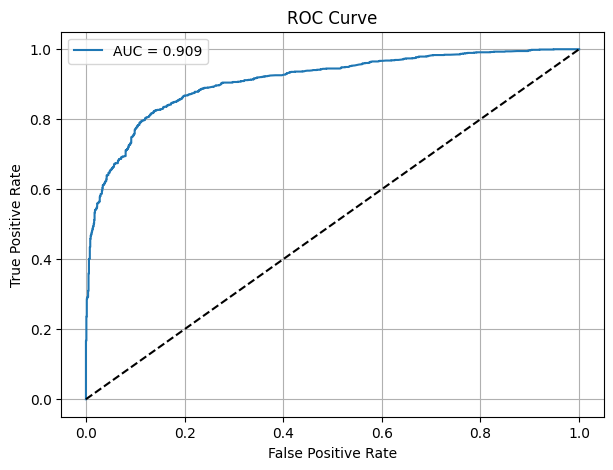

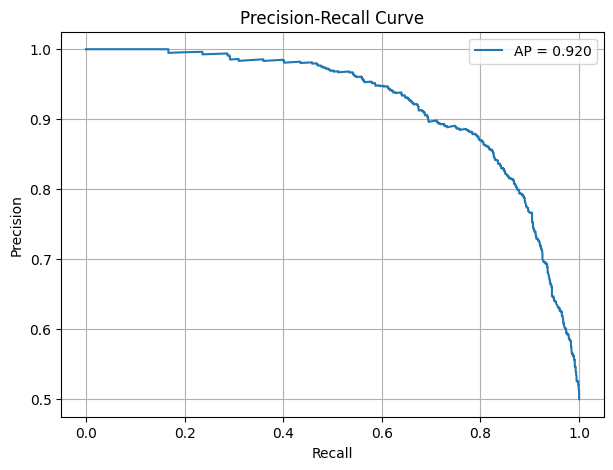

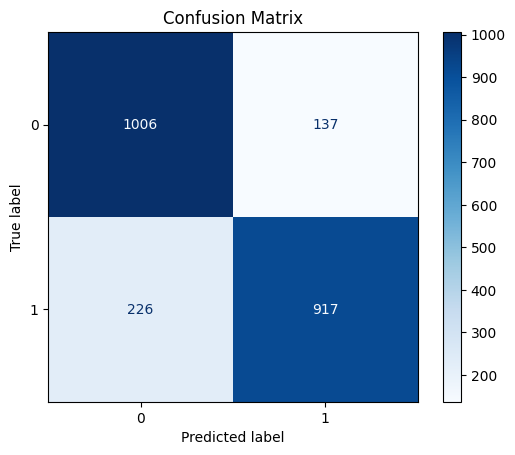

⚠️ Permutation importance not supported or failed: name 'model' is not defined
⚠️ SHAP visualization skipped: name 'wrapped_model' is not defined


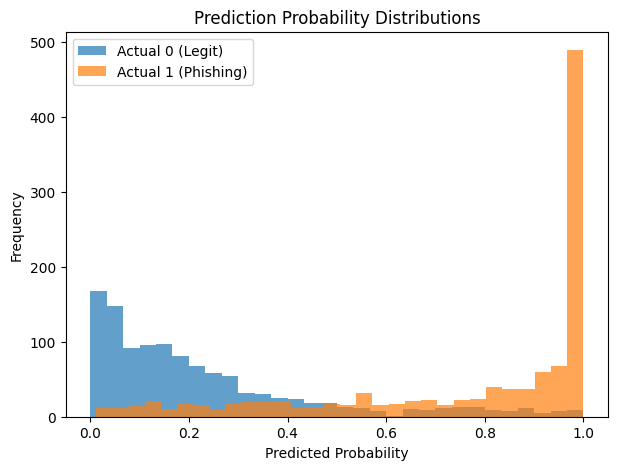

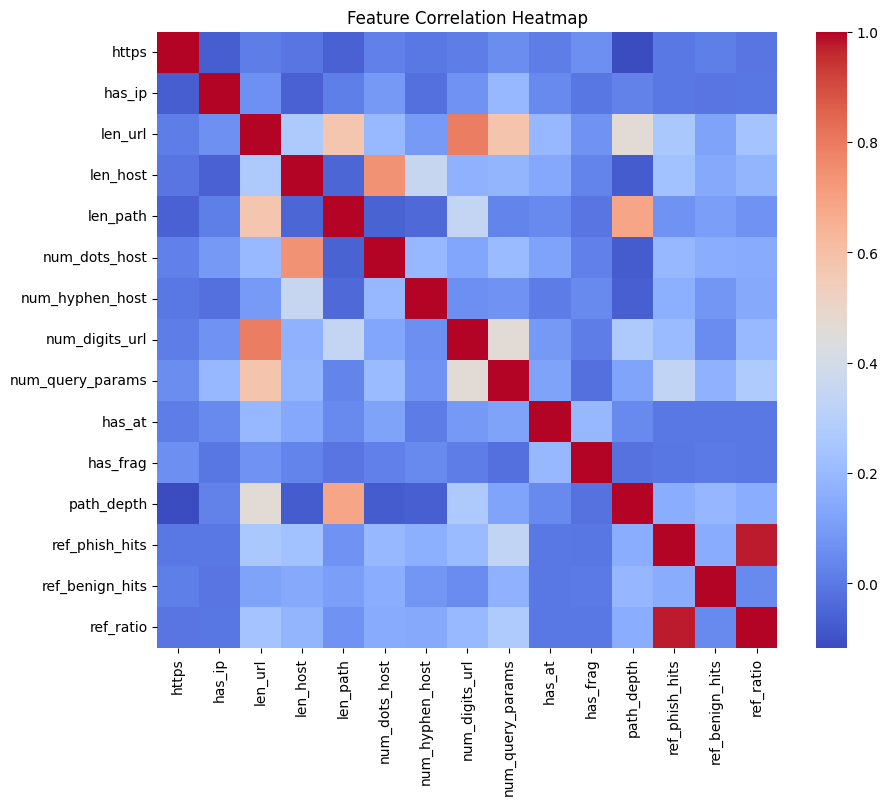

In [26]:
# =========================
# MODEL VISUALIZATION CELLS
# =========================

# 1️ ROC Curve & AUC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_va, probs_va)
auc = roc_auc_score(y_va, probs_va)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


# 2️ Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_va, probs_va)
ap = average_precision_score(y_va, probs_va)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()


# 3️ Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_va, (probs_va > 0.5).astype(int))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


# 4️ Feature Importance (Permutation Importance)
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

try:
    # Note: Permutation importance requires the model to have a predict_proba or decision_function method
    # and accept numpy arrays as input. RefTABMNet wraps a PyTorch model, so we'll need to use the RefTABMNet instance.
    # Also, permutation importance expects the model to be fit on the training data, but we are evaluating on validation.
    # To properly calculate permutation importance, we should ideally use the trained model and the validation data.
    # We also need the feature names, which are stored in `feature_keys`.

    # Ensure X_va is a pandas DataFrame with feature names for permutation importance
    X_va_df = pd.DataFrame(X_va, columns=feature_keys)

    # We need to wrap the RefTABMNet predict_proba method to be compatible with permutation_importance
    class PermutationImportanceWrapper:
        def __init__(self, model_instance):
            self.model_instance = model_instance

        def predict_proba(self, X):
            # Ensure input is numpy array as expected by RefTABMNet.predict_proba
            if isinstance(X, pd.DataFrame):
                X = X.values
            return self.model_instance.predict_proba(X)

    wrapped_model = PermutationImportanceWrapper(model)

    perm_result = permutation_importance(wrapped_model, X_va_df, y_va, scoring='roc_auc', n_repeats=5, random_state=42)
    importances = pd.Series(perm_result.importances_mean, index=X_va_df.columns).sort_values(ascending=False)
    plt.figure(figsize=(8,5))
    importances.head(15).plot(kind='bar')
    plt.title('Top Feature Importances (Permutation Importance)')
    plt.ylabel('Importance')
    plt.show()
except Exception as e:
    print("⚠️ Permutation importance not supported or failed:", e)


# 5️ SHAP Summary Plot (Deep Explainability)
try:
    import shap

    # SHAP requires the model to predict on numpy arrays and return numpy arrays
    # We need to adapt the RefTABMNet model for SHAP.
    # Using the wrapped model from permutation importance
    explainer = shap.Explainer(wrapped_model.predict_proba, X_va_df)
    shap_values = explainer(X_va_df)

    # SHAP summary plot expects shap_values to be a shap.Explanation object
    # If it's an array, we might need to create an Explanation object
    if isinstance(shap_values, np.ndarray):
         shap_values = shap.Explanation(shap_values, data=X_va_df.values, feature_names=X_va_df.columns)


    shap.summary_plot(shap_values, X_va_df, plot_type="bar")
except Exception as e:
    print("⚠️ SHAP visualization skipped:", e)


# 6  Predicted vs Actual Distribution
plt.figure(figsize=(7,5))
plt.hist(probs_va[y_va==0], bins=30, alpha=0.7, label='Actual 0 (Legit)')
plt.hist(probs_va[y_va==1], bins=30, alpha=0.7, label='Actual 1 (Phishing)')
plt.title('Prediction Probability Distributions')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# 7️ Correlation Heatmap of Features
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X_va, columns=feature_keys).corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()